In [72]:
import kagglehub

path = kagglehub.dataset_download("salader/dogsvscats")
print(path)

/kaggle/input/datasets/salader/dogsvscats


In [73]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/salader/dogsvscats"):
    print(root)

/kaggle/input/datasets/salader/dogsvscats
/kaggle/input/datasets/salader/dogsvscats/test
/kaggle/input/datasets/salader/dogsvscats/test/dogs
/kaggle/input/datasets/salader/dogsvscats/test/cats
/kaggle/input/datasets/salader/dogsvscats/train
/kaggle/input/datasets/salader/dogsvscats/train/dogs
/kaggle/input/datasets/salader/dogsvscats/train/cats
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test/dogs
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/test/cats
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train/dogs
/kaggle/input/datasets/salader/dogsvscats/catsvsdogs/train/cats


In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    RandomRotation,
    RandomTranslation,
    RandomFlip,
    Rescaling,
    InputLayer,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [75]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/salader/dogsvscats/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(150,150),
    batch_size=32,
    shuffle=True
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/salader/dogsvscats/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(150,150),
    batch_size=32,
    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/salader/dogsvscats/test",
    image_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.
Found 20000 files belonging to 2 classes.
Using 4000 files for validation.
Found 5000 files belonging to 2 classes.


In [76]:
print(train_ds.class_names)

['cats', 'dogs']


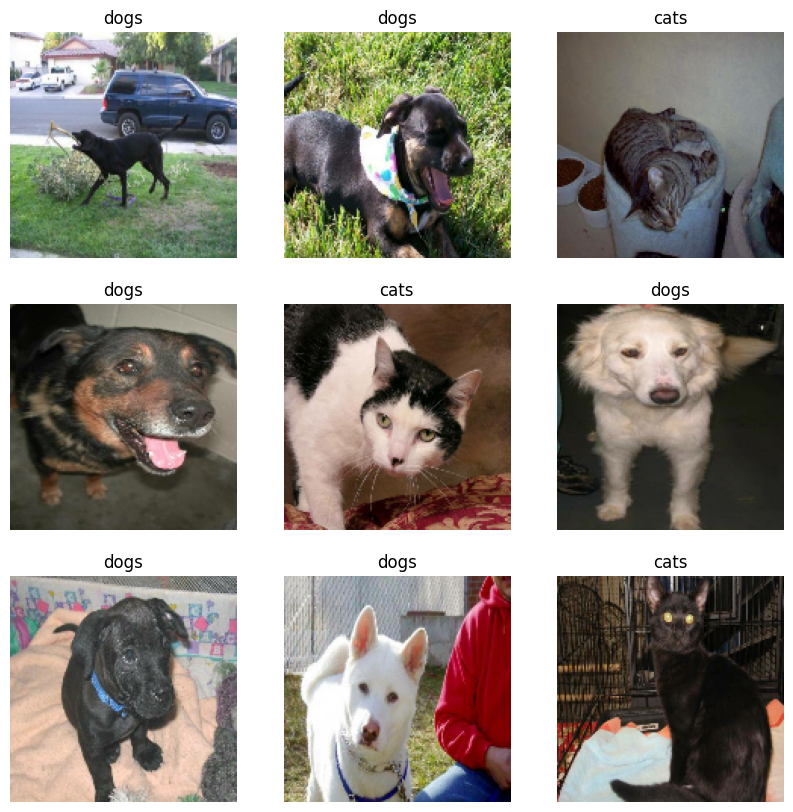

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [78]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [79]:
# data augmentation
# 15/360 tells Keras to rotate randomly within a range of -15 to +15 degrees
data_augmentation = Sequential([
    RandomRotation(15 / 360),
    RandomTranslation(height_factor=0.1, width_factor=0.1),
    RandomFlip("horizontal")
])

# build architecture

model = Sequential([
    # Step A: Define the explicit image input size
    InputLayer(input_shape=(150, 150, 3)),
    Rescaling(1./255),
    # Step B: Apply GPU-accelerated transformations (skipped automatically during validation)
    data_augmentation,
    
    # First Convolution Block
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Second Convolution Block
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Third Convolution Block
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Fourth Convolution Block
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Flatten & Fully Connected Classifier Block
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # Ideal output layer for binary classification (Cats vs Dogs)
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,634,881 (13.87 MB)

 Trainable params: 3,633,921 (13.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [80]:
#Early stopping
import tensorflow.keras.callbacks as callbacks
early_stopping =  callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=10, # how many epochs to wait before stopping
    restore_best_weights=True,
    verbose=1,
)


In [81]:
model.compile( optimizer='adam' ,loss='binary_crossentropy',metrics=["accuracy"])

In [82]:
# train model
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)
model_history=model.fit(train_ds, epochs=15, validation_data=val_ds,callbacks=[early_stopping,checkpoint])

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 64ms/step - accuracy: 0.5924 - loss: 0.8140 - val_accuracy: 0.2903 - val_loss: 0.8846
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 60ms/step - accuracy: 0.6835 - loss: 0.5950 - val_accuracy: 0.0793 - val_loss: 1.4400
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.7431 - loss: 0.5198 - val_accuracy: 0.8150 - val_loss: 0.3951
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.7936 - loss: 0.4498 - val_accuracy: 0.9540 - val_loss: 0.2234
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.8321 - loss: 0.3749 - val_accuracy: 0.6410 - val_loss: 0.8162
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.8582 - loss: 0.3307 - val_accuracy: 0.7440 - val_loss: 0.4977
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.8754 - loss: 0.2975 - val_accuracy: 0.8292 - val_loss: 0.3839
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.8912 - loss: 0.2700 - 

In [83]:
model.save("cats_dogs_model.keras")

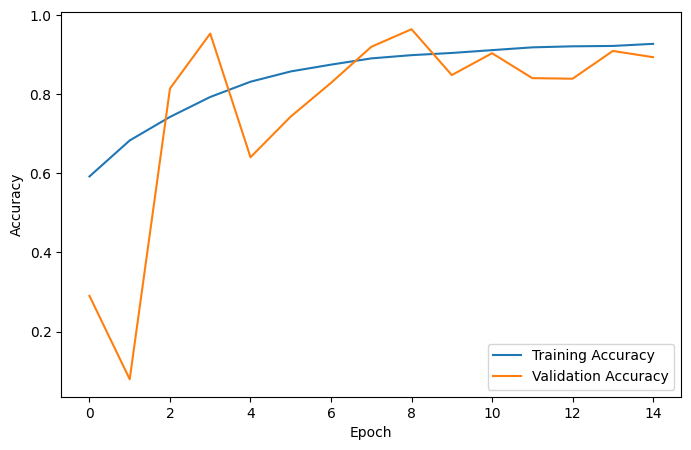

In [84]:

plt.figure(figsize=(8,5))

plt.plot(model_history.history['accuracy'],label='Training Accuracy')
plt.plot(model_history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

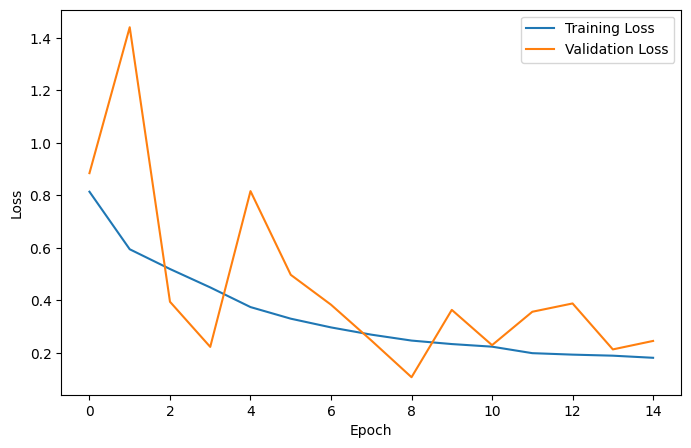

In [85]:
plt.figure(figsize=(8,5))

plt.plot(model_history.history['loss'],label='Training Loss')
plt.plot(model_history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [86]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8962 - loss: 0.2370
Test Loss: 0.23703715205192566
Test Accuracy: 0.8962000012397766


In [87]:
# predict output
class_names = ["cat", "dog"]
y_true = []
X=[]
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    X.extend(images)
y_true = np.array(y_true)
print("Actual :",class_names[y_true[1]])
y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
print("Predicted :",class_names[y_pred[1]])

Actual : cat
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
Predicted : cat


In [88]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.83      0.89      2500
           1       0.85      0.96      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



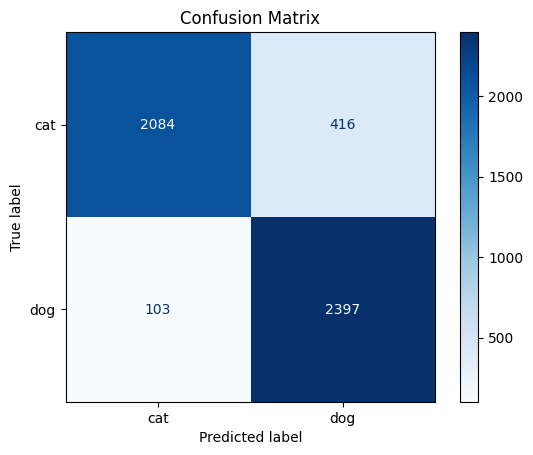

In [89]:
# print confusion matrix

ConfusionMatrixDisplay.from_predictions(
   y_true,y_pred,
    display_labels=class_names,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

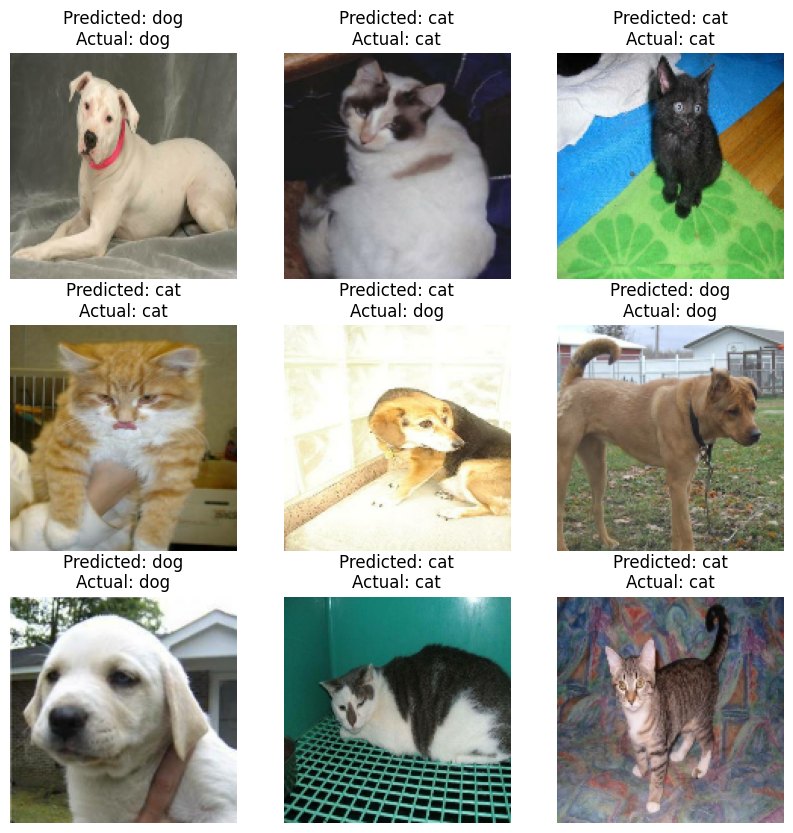

In [90]:
import matplotlib.pyplot as plt
import numpy as np

images_list = []
labels_list = []

for images, labels in test_ds:
    images_list.extend(images.numpy())
    labels_list.extend(labels.numpy())

images_list = np.array(images_list)
labels_list = np.array(labels_list)


plt.figure(figsize=(10,10))

for i in range(9):
    index = np.random.randint(len(images_list))

    plt.subplot(3,3,i+1)
    plt.imshow(images_list[index].astype("uint8"))

    plt.title(
        f"Predicted: {class_names[y_pred[index]]}\n"
        f"Actual: {class_names[labels_list[index]]}"
    )

    plt.axis("off")

plt.show()